In [3]:
# Install required libraries (quiet mode to keep the log clean)
!pip install -q timm==1.0.11
!pip install -q torchmetrics==1.4.2
!pip install -q scikit-learn==1.5.2
!pip install -q tqdm==4.66.5

print("Dependencies installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 34.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.2/869.2 kB 13.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 87.3 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tpot 1.1.0 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
category-encoders 2.9.0 requires scikit-learn>=1.6.0, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 2.3 MB/s eta 0:00:00

In [4]:
# Standard library
import os
import copy
import time
import random
import warnings
from pathlib import Path

# Numerical / data handling
import numpy as np
import pandas as pd

# Image handling
import cv2
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
from torchvision import transforms

# MaxViT backbone (hybrid CNN + multi-axis attention)
import timm

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
)
from sklearn.model_selection import train_test_split

# Progress bars
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

In [5]:
# ----------------------------------------------------------------
# Reproducibility
# ----------------------------------------------------------------
SEED = 42

def set_seed(seed: int = SEED) -> None:
    """Fix random seeds across all relevant libraries for reproducible runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# ----------------------------------------------------------------
# Device detection
# ----------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")

Using device: cuda
GPU: Tesla T4 (15.6 GB)


In [6]:
DATA_DIR = "/kaggle/input/datasets/mariaherrerot/aptos2019"

print(os.listdir(DATA_DIR))

['val_images', 'train_images', 'valid.csv', 'test.csv', 'train_1.csv', 'test_images']


In [7]:
TRAIN_CSV = os.path.join(DATA_DIR, "train_1.csv")
VALID_CSV = os.path.join(DATA_DIR, "valid.csv")

train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)

print(train_df.head())
print(train_df.columns)

        id_code  diagnosis
0  1ae8c165fd53          2
1  1b329a127307          1
2  1b32e1d775ea          4
3  1b3647865779          0
4  1b398c0494d1          0
Index(['id_code', 'diagnosis'], dtype='object')


In [8]:
# Images live in nested train_images/train_images and val_images/val_images
TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train_images", "train_images")
VALID_IMG_DIR = os.path.join(DATA_DIR, "val_images", "val_images")

train_df["file_path"] = train_df["id_code"].apply(
    lambda x: os.path.join(TRAIN_IMG_DIR, f"{x}.png")
)

valid_df["file_path"] = valid_df["id_code"].apply(
    lambda x: os.path.join(VALID_IMG_DIR, f"{x}.png")
)

print(train_df.head())
print(valid_df.head())

# Sanity check that the first image actually resolves
print(os.path.exists(train_df.loc[0, "file_path"]))

        id_code  diagnosis                                          file_path
0  1ae8c165fd53          2  /kaggle/input/datasets/mariaherrerot/aptos2019...
1  1b329a127307          1  /kaggle/input/datasets/mariaherrerot/aptos2019...
2  1b32e1d775ea          4  /kaggle/input/datasets/mariaherrerot/aptos2019...
3  1b3647865779          0  /kaggle/input/datasets/mariaherrerot/aptos2019...
4  1b398c0494d1          0  /kaggle/input/datasets/mariaherrerot/aptos2019...
        id_code  diagnosis                                          file_path
0  000c1434d8d7          2  /kaggle/input/datasets/mariaherrerot/aptos2019...
1  001639a390f0          4  /kaggle/input/datasets/mariaherrerot/aptos2019...
2  0024cdab0c1e          1  /kaggle/input/datasets/mariaherrerot/aptos2019...
3  002c21358ce6          0  /kaggle/input/datasets/mariaherrerot/aptos2019...
4  005b95c28852          0  /kaggle/input/datasets/mariaherrerot/aptos2019...
True


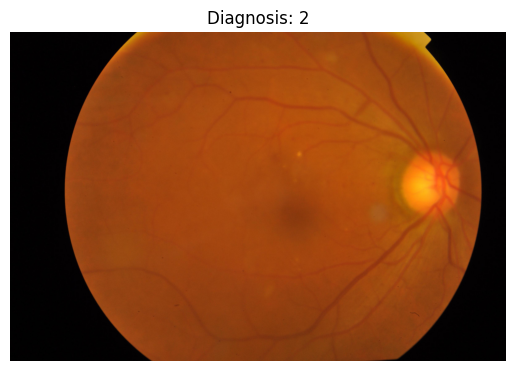

In [9]:
img = Image.open(train_df.loc[0, "file_path"])

plt.imshow(img)
plt.axis("off")
plt.title(f'Diagnosis: {train_df.loc[0, "diagnosis"]}')
plt.show()

In [10]:
# Pytorch

class APTOSDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "file_path"]
        label = int(self.df.loc[idx, "diagnosis"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [11]:
# MaxViT (tf variants) expects 224x224 inputs, same as the ViT baseline
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

valid_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:
train_dataset = APTOSDataset(train_df, transform=train_transform)
valid_dataset = APTOSDataset(valid_df, transform=valid_transform)

print(len(train_dataset))
print(len(valid_dataset))

image, label = train_dataset[0]
print(image.shape)
print(label)

2930
366
torch.Size([3, 224, 224])
2


In [13]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")

# Verify the loader
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)
print(labels)

Train batches: 92
Validation batches: 12
torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor([2, 0, 0, 0, 2, 0, 3, 0, 2, 0, 0, 3, 0, 4, 2, 0, 4, 3, 2, 0, 3, 4, 0, 1,
        0, 3, 2, 0, 0, 2, 4, 2])


In [14]:
## Build the MaxViT model

MODEL_NAME = "maxvit_tiny_tf_224"
NUM_CLASSES = 5

model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {MODEL_NAME}")
print(f"Total params    : {n_params/1e6:.2f}M")
print(f"Trainable params: {n_trainable/1e6:.2f}M")
print(f"Device: {device}")

model.safetensors:   0%|          | 0.00/124M [00:00<?, ?B/s]

Model: maxvit_tiny_tf_224
Total params    : 30.41M
Trainable params: 30.41M
Device: cuda


In [15]:
# Quick forward pass sanity check
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)

print(outputs.shape)  # expected: [BATCH_SIZE, NUM_CLASSES]
model.train()

torch.Size([32, 5])


MaxxVit(
  (stem): Stem(
    (conv1): Conv2dSame(3, 64, kernel_size=(3, 3), stride=(2, 2))
    (norm1): BatchNormAct2d(
      64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): GELUTanh()
    )
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (stages): Sequential(
    (0): MaxxVitStage(
      (blocks): Sequential(
        (0): MaxxVitBlock(
          (conv): MbConvBlock(
            (shortcut): Downsample2d(
              (pool): AvgPool2dSame(kernel_size=(2, 2), stride=(2, 2), padding=(0, 0))
              (expand): Identity()
            )
            (pre_norm): BatchNormAct2d(
              64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): Identity()
            )
            (down): Identity()
            (conv1_1x1): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (norm1): BatchNormAct2d(
      

In [16]:
## Loss, optimizer, scheduler

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

EPOCHS = 15

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

In [17]:
## Training and validation functions

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds, all_labels = [], []

    progress_bar = tqdm(loader, desc="Validating", leave=False)

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            progress_bar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)

In [18]:
## Training configuration

BEST_MODEL_PATH = "best_maxvit_model.pth"

best_accuracy = 0.0
best_qwk = -1.0

train_losses = []
valid_losses = []

train_accuracies = []
valid_accuracies = []

In [19]:
## Main training loop

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    valid_loss, valid_acc, y_true, y_pred = validate(
        model, valid_loader, criterion, device
    )

    scheduler.step()

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    train_accuracies.append(train_acc)
    valid_accuracies.append(valid_acc)

    epoch_qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")
    print(f"Valid Loss : {valid_loss:.4f}")
    print(f"Valid Acc  : {valid_acc:.4f}")
    print(f"Valid QWK  : {epoch_qwk:.4f}")

    if valid_acc > best_accuracy:
        best_accuracy = valid_acc
        best_qwk = epoch_qwk
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"New best model saved (Valid Acc: {best_accuracy:.4f})")

print("\nTraining complete.")
print(f"Best Valid Accuracy: {best_accuracy:.4f}")
print(f"Best Valid QWK     : {best_qwk:.4f}")


Epoch 1/15
----------------------------------------


Training:   0%|          | 0/92 [00:00<?, ?it/s]

Validating:   0%|          | 0/12 [00:00<?, ?it/s]

Train Loss : 0.9153
Train Acc  : 0.6809
Valid Loss : 0.6844
Valid Acc  : 0.7404
Valid QWK  : 0.7987
New best model saved (Valid Acc: 0.7404)

Epoch 2/15
----------------------------------------


Training:   0%|          | 0/92 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/12 [00:00<?, ?it/s]

Train Loss : 0.2380
Train Acc  : 0.9171
Valid Loss : 0.4593
Valid Acc  : 0.8388
Valid QWK  : 0.8889

Epoch 15/15
----------------------------------------


Training:   0%|          | 0/92 [00:00<?, ?it/s]

Validating:   0%|          | 0/12 [00:00<?, ?it/s]

Train Loss : 0.2336
Train Acc  : 0.9181
Valid Loss : 0.4579
Valid Acc  : 0.8333
Valid QWK  : 0.8878

Training complete.
Best Valid Accuracy: 0.8443
Best Valid QWK     : 0.8937


In [20]:
## Comprehensive evaluation

class_names = {0: "No DR", 1: "Mild", 2: "Moderate", 3: "Severe", 4: "Proliferative DR"}

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(valid_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")

print(f"Accuracy         : {acc:.4f}")
print(f"Precision (wtd)  : {precision:.4f}")
print(f"Recall (wtd)     : {recall:.4f}")
print(f"F1 (wtd)         : {f1:.4f}")
print(f"Quadratic Kappa  : {qwk:.4f}")
print()
print(classification_report(
    all_labels, all_preds,
    target_names=list(class_names.values()),
    zero_division=0
))

Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

Accuracy         : 0.8443
Precision (wtd)  : 0.8392
Recall (wtd)     : 0.8443
F1 (wtd)         : 0.8369
Quadratic Kappa  : 0.8937

                  precision    recall  f1-score   support

           No DR       0.99      0.99      0.99       172
            Mild       0.70      0.57      0.63        40
        Moderate       0.75      0.88      0.81       104
          Severe       0.67      0.36      0.47        22
Proliferative DR       0.58      0.54      0.56        28

        accuracy                           0.84       366
       macro avg       0.74      0.67      0.69       366
    weighted avg       0.84      0.84      0.84       366



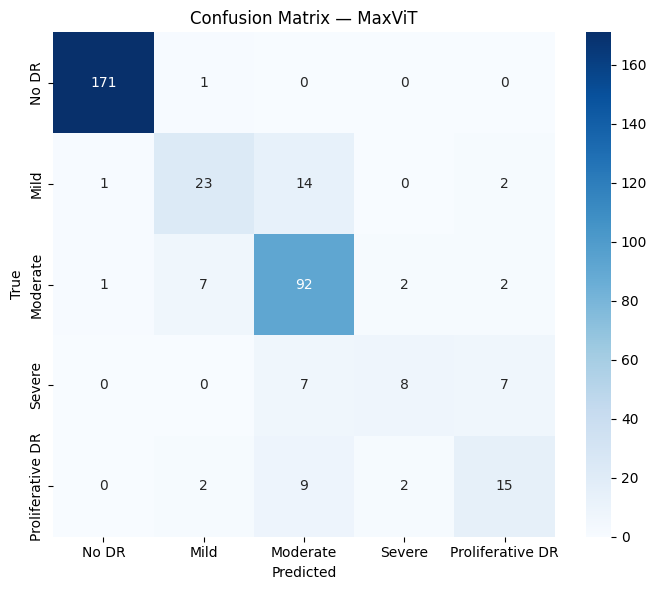

In [21]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=list(class_names.values()),
    yticklabels=list(class_names.values())
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — MaxViT")
plt.tight_layout()
plt.show()

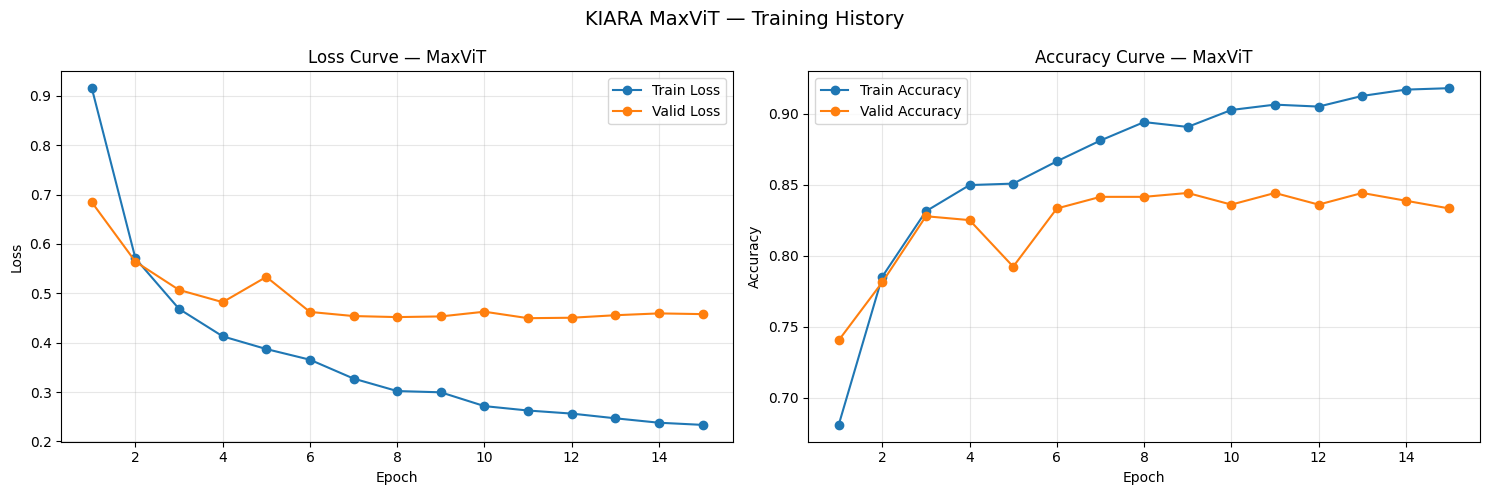

In [22]:
# Training Curves

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, label="Train Loss", marker="o")
axes[0].plot(epochs_range, valid_losses, label="Valid Loss", marker="o")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve — MaxViT")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, train_accuracies, label="Train Accuracy", marker="o")
axes[1].plot(epochs_range, valid_accuracies, label="Valid Accuracy", marker="o")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curve — MaxViT")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("KIARA MaxViT — Training History", fontsize=14)
plt.tight_layout()
plt.show()

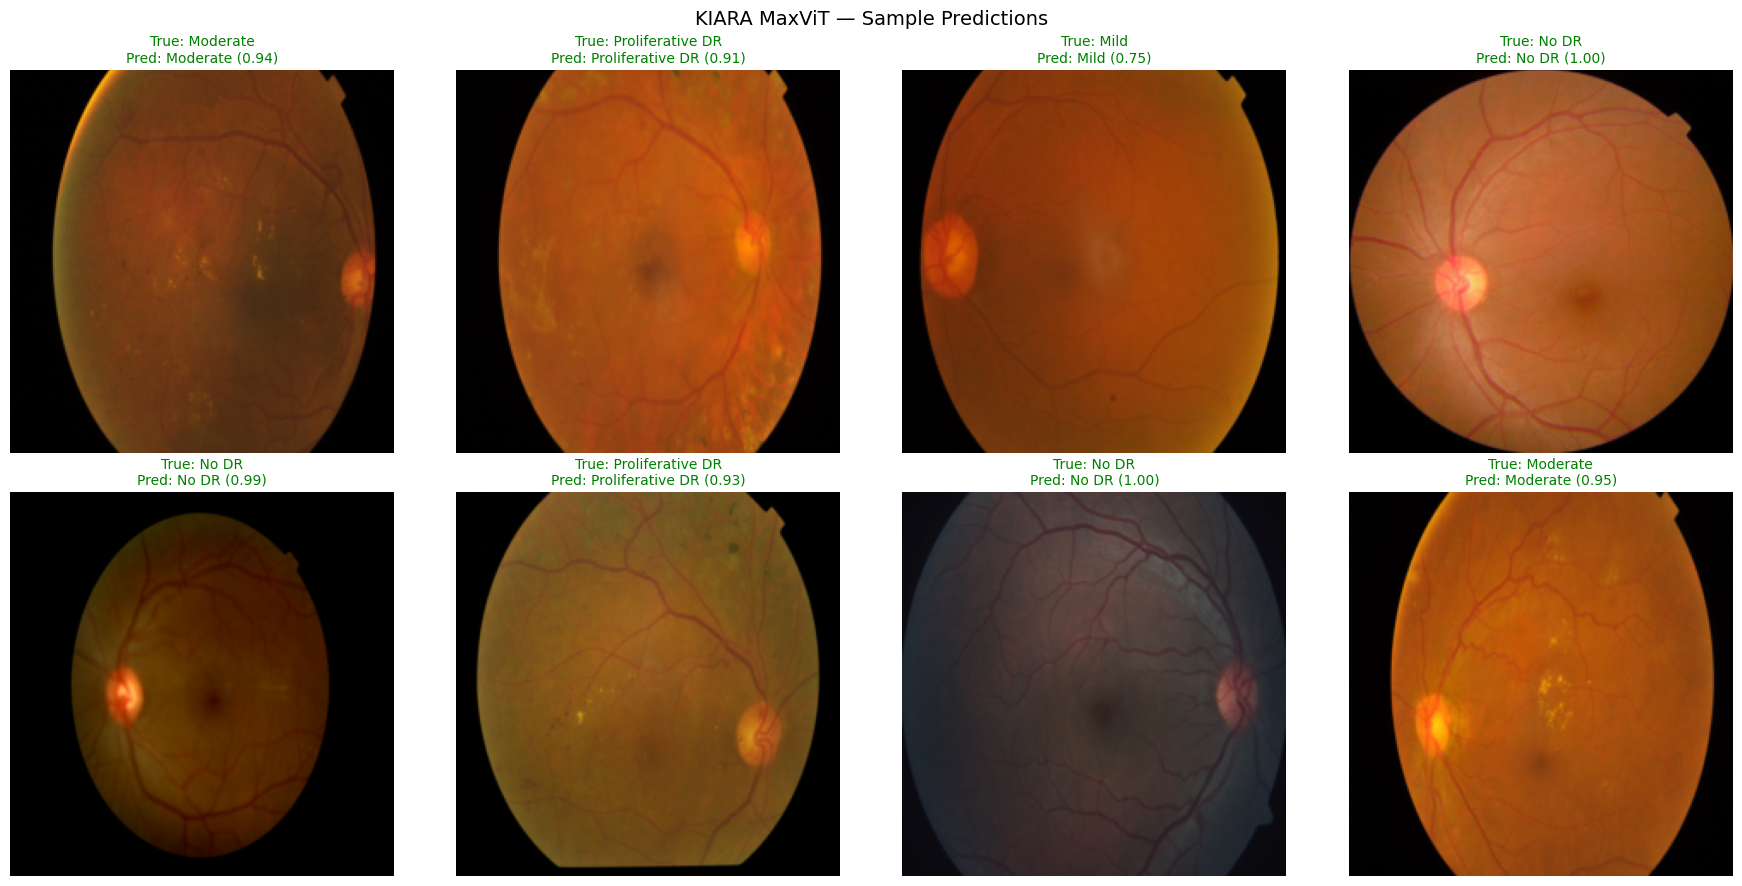

In [26]:
## Prediction visualization

def denormalize(tensor_img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    img = tensor_img.clone().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)

vis_images, vis_labels = next(iter(valid_loader))
vis_images_device = vis_images.to(device)

model.eval()
with torch.no_grad():
    outputs = model(vis_images_device)
    probs = torch.softmax(outputs, dim=1)
    confidences, preds = torch.max(probs, dim=1)

n_display = min(8, len(vis_images))
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i in range(n_display):
    img = denormalize(vis_images[i])
    true_label = vis_labels[i].item()
    pred_label = preds[i].item()
    confidence = confidences[i].item()
    color = "green" if pred_label == true_label else "red"

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(
        f"True: {class_names[true_label]}\n"
        f"Pred: {class_names[pred_label]} ({confidence:.2f})",
        color=color, fontsize=10
    )

for j in range(n_display, len(axes)):
    axes[j].axis("off")

plt.suptitle("KIARA MaxViT — Sample Predictions", fontsize=14)
plt.tight_layout()
plt.show()

In [28]:
## Save the final model

FINAL_MODEL_PATH = "kiara_maxvit_final.pth"
torch.save(model.state_dict(), FINAL_MODEL_PATH)

torch.save({
    "model_state_dict": model.state_dict(),
    "model_name": MODEL_NAME,
    "num_classes": NUM_CLASSES,
    "class_names": class_names,
    "img_size": IMG_SIZE,
    "imagenet_mean": [0.485, 0.456, 0.406],
    "imagenet_std": [0.229, 0.224, 0.225],
    "best_val_accuracy": float(best_accuracy),
    "qwk": float(qwk),
}, "kiara_maxvit_checkpoint.pth")

print(f"Final model weights saved to : {FINAL_MODEL_PATH}")
print("Rich checkpoint saved to      : kiara_maxvit_checkpoint.pth")

Final model weights saved to : kiara_maxvit_final.pth
Rich checkpoint saved to      : kiara_maxvit_checkpoint.pth
